Notebook 1 : Exploration


---


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "cityscapes"
GT_ROOT = DATA_ROOT / "gtFine"
IMG_ROOT = DATA_ROOT / "leftImg8bit"

OUT_DIR = PROJECT_ROOT / "out" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GT_ROOT     :", GT_ROOT)
print("IMG_ROOT    :", IMG_ROOT)

if not GT_ROOT.exists() or not IMG_ROOT.exists():
    raise FileNotFoundError(
        "Dataset introuvable: vérifie data/raw/cityscapes/{gtFine,leftImg8bit}"
    )

PROJECT_ROOT: /home/ui/PROJ8
GT_ROOT     : /home/ui/PROJ8/data/raw/cityscapes/gtFine
IMG_ROOT    : /home/ui/PROJ8/data/raw/cityscapes/leftImg8bit


In [2]:
SPLITS_DISK = ("train", "val", "test")


def list_left_images(split: str):
    return sorted((IMG_ROOT / split).rglob("*_leftImg8bit.png"))


def mask_labelIds_path(img_path: Path) -> Path:
    city = img_path.parent.name
    split = img_path.parent.parent.name
    stem = img_path.name.replace("_leftImg8bit.png", "")
    return GT_ROOT / split / city / f"{stem}_gtFine_labelIds.png"


rows = []
for split in SPLITS_DISK:
    for img_path in list_left_images(split):
        mpath = mask_labelIds_path(img_path)
        rows.append(
            {
                "split_disk": split,
                "city": img_path.parent.name,
                "image_id": img_path.stem.replace("_leftImg8bit", ""),
                "image_path": str(img_path),
                "mask_labelIds_path": str(mpath),
                "mask_exists": mpath.exists(),
            }
        )

df = pd.DataFrame(rows)
print("Index shape:", df.shape)
df.head(3000)

Index shape: (5000, 6)


,split_disk,city,image_id,image_path,mask_labelIds_path,mask_exists
0,train,aachen,aachen_000000_000019,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/trai...,True
1,train,aachen,aachen_000001_000019,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/trai...,True
2,train,aachen,aachen_000002_000019,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/trai...,True
3,train,aachen,aachen_000003_000019,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/trai...,True
4,train,aachen,aachen_000004_000019,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/trai...,True
...,...,...,...,...,...,...
2995,val,frankfurt,frankfurt_000000_009969,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/val/...,True
2996,val,frankfurt,frankfurt_000000_010351,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/val/...,True
2997,val,frankfurt,frankfurt_000000_010763,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/val/...,True
2998,val,frankfurt,frankfurt_000000_011007,/home/ui/PROJ8/data/raw/cityscapes/leftImg8bit...,/home/ui/PROJ8/data/raw/cityscapes/gtFine/val/...,True


In [3]:
completion = (
    df.groupby("split_disk")
    .agg(n_images=("image_id", "count"), pct_mask_exists=("mask_exists", "mean"))
    .reset_index()
)
completion["pct_mask_exists"] = (100 * completion["pct_mask_exists"]).round(2)
completion

,split_disk,n_images,pct_mask_exists
0,test,1525,100.0
1,train,2975,100.0
2,val,500,100.0


In [4]:
def parse_image_id_from_left(path: Path) -> str:
    return path.name.replace("_leftImg8bit.png", "")


def parse_image_id_from_label(path: Path) -> str:
    return path.name.replace("_gtFine_labelIds.png", "")


def build_id_set_left(split: str):
    return set(
        parse_image_id_from_left(p)
        for p in (IMG_ROOT / split).rglob("*_leftImg8bit.png")
    )


def build_id_set_label(split: str):
    return set(
        parse_image_id_from_label(p)
        for p in (GT_ROOT / split).rglob("*_gtFine_labelIds.png")
    )


audit_rows = []
for split in ("train", "val", "test"):
    ids_left = build_id_set_left(split)
    ids_lab = build_id_set_label(split)
    audit_rows.append(
        {
            "split": split,
            "n_left": len(ids_left),
            "n_labelIds": len(ids_lab),
            "left_without_label": len(ids_left - ids_lab),
            "label_without_left": len(ids_lab - ids_left),
        }
    )

audit_pairs = pd.DataFrame(audit_rows)
audit_pairs

,split,n_left,n_labelIds,left_without_label,label_without_left
0,train,2975,2975,0,0
1,val,500,500,0,0
2,test,1525,1525,0,0


In [5]:
missing = df[~df["mask_exists"]].copy()
print("Nb images sans mask_labelIds:", len(missing))
missing.head(10)

Nb images sans mask_labelIds: 0


,split_disk,city,image_id,image_path,mask_labelIds_path,mask_exists


In [6]:
def count_files(root: Path, split: str, pattern: str) -> int:
    return len(list((root / split).rglob(pattern)))


patterns_gt = {
    "labelIds": "*_gtFine_labelIds.png",
    "color": "*_gtFine_color.png",
    "instanceIds": "*_gtFine_instanceIds.png",
    "polygons": "*_gtFine_polygons.json",
}
patterns_img = {
    "leftImg8bit": "*_leftImg8bit.png",
}

rows = []
for split in ("train", "val", "test"):
    r = {"split": split}
    for k, pat in patterns_gt.items():
        r[f"gtFine_{k}"] = count_files(GT_ROOT, split, pat)
    for k, pat in patterns_img.items():
        r[f"left_{k}"] = count_files(IMG_ROOT, split, pat)
    rows.append(r)

inv = pd.DataFrame(rows)
inv

,split,gtFine_labelIds,gtFine_color,gtFine_instanceIds,gtFine_polygons,left_leftImg8bit
0,train,2975,2975,2975,2975,2975
1,val,500,500,500,500,500
2,test,1525,1525,1525,1525,1525


In [7]:
def img_size(path: str):
    with Image.open(path) as im:
        return im.size


sample = (
    df[df["mask_exists"]]
    .sample(min(200, (df["mask_exists"]).sum()), random_state=0)
    .copy()
)
sample["img_size"] = sample["image_path"].apply(img_size)
sample["mask_size"] = sample["mask_labelIds_path"].apply(img_size)

match_rate = (sample["img_size"] == sample["mask_size"]).mean()
print("Taux tailles identiques (échantillon):", round(match_rate, 4))

sample[["split_disk", "img_size", "mask_size"]].head(5)

Taux tailles identiques (échantillon): 1.0


,split_disk,img_size,mask_size
398,train,"(2048, 1024)","(2048, 1024)"
3833,test,"(2048, 1024)","(2048, 1024)"
4836,test,"(2048, 1024)","(2048, 1024)"
4572,test,"(2048, 1024)","(2048, 1024)"
636,train,"(2048, 1024)","(2048, 1024)"


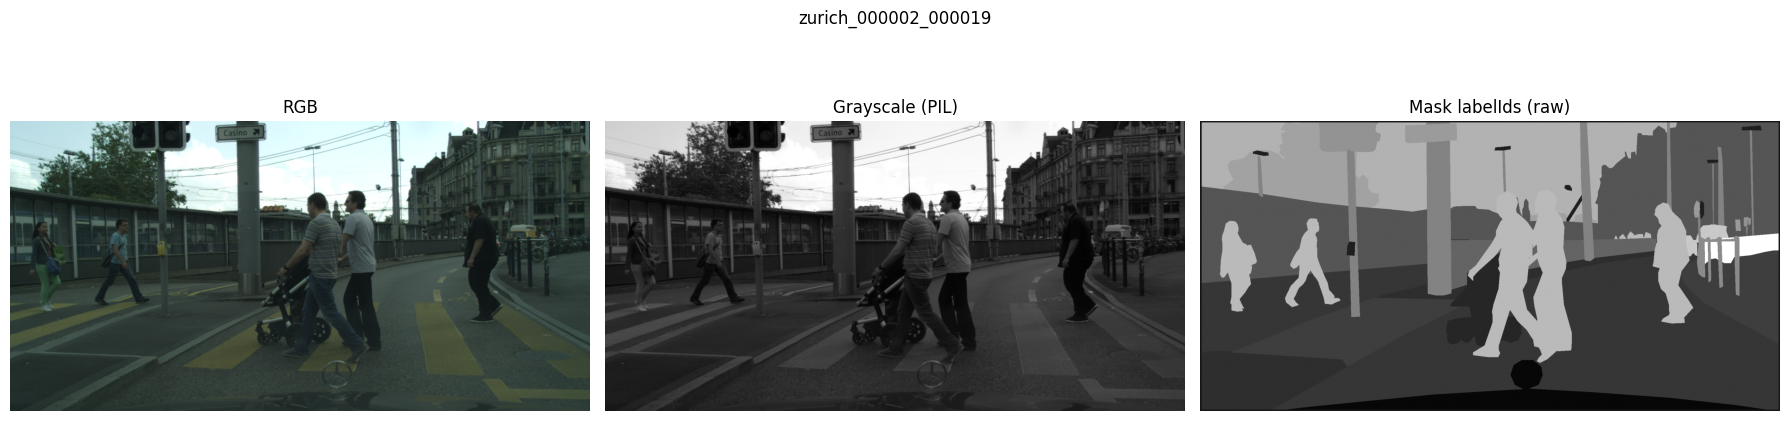

In [8]:
def load_rgb(path: str):
    return Image.open(path).convert("RGB")


def load_mask(path: str):
    return Image.open(path)


row = (
    df[(df["split_disk"] == "train") & (df["mask_exists"])]
    .sample(1, random_state=0)
    .iloc[0]
)
img = load_rgb(row["image_path"])
gray = img.convert("L")
mask = load_mask(row["mask_labelIds_path"])

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(img)
ax[0].set_title("RGB")
ax[0].axis("off")
ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Grayscale (PIL)")
ax[1].axis("off")
ax[2].imshow(mask, cmap="gray")
ax[2].set_title("Mask labelIds (raw)")
ax[2].axis("off")
plt.suptitle(row["image_id"])
plt.tight_layout()
plt.show()

In [9]:
CATEGORY_NAMES = [
    "void",
    "flat",
    "construction",
    "object",
    "nature",
    "sky",
    "human",
    "vehicle",
]
IGNORE_LABEL = 255
N_CLASSES = 8

LABELID_TO_CATEGORY = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 1,
    7: 1,
    8: 1,
    9: 1,
    10: 1,
    11: 2,
    12: 2,
    13: 2,
    14: 2,
    15: 2,
    16: 2,
    17: 3,
    18: 3,
    19: 3,
    20: 3,
    21: 4,
    22: 4,
    23: 5,
    24: 6,
    25: 6,
    26: 7,
    27: 7,
    28: 7,
    29: 7,
    30: 7,
    31: 7,
    32: 7,
    33: 7,
}

LUT = np.zeros((256,), dtype=np.uint8)
for k, v in LABELID_TO_CATEGORY.items():
    LUT[k] = v
LUT[IGNORE_LABEL] = IGNORE_LABEL


def remap_to_groups(mask_pil: Image.Image, ignore_to_void: bool = False) -> Image.Image:
    arr = np.array(mask_pil, dtype=np.uint16)
    out = LUT[arr]
    if ignore_to_void:
        out = out.copy()
        out[out == IGNORE_LABEL] = 0
    return Image.fromarray(out.astype(np.uint8), mode="L")

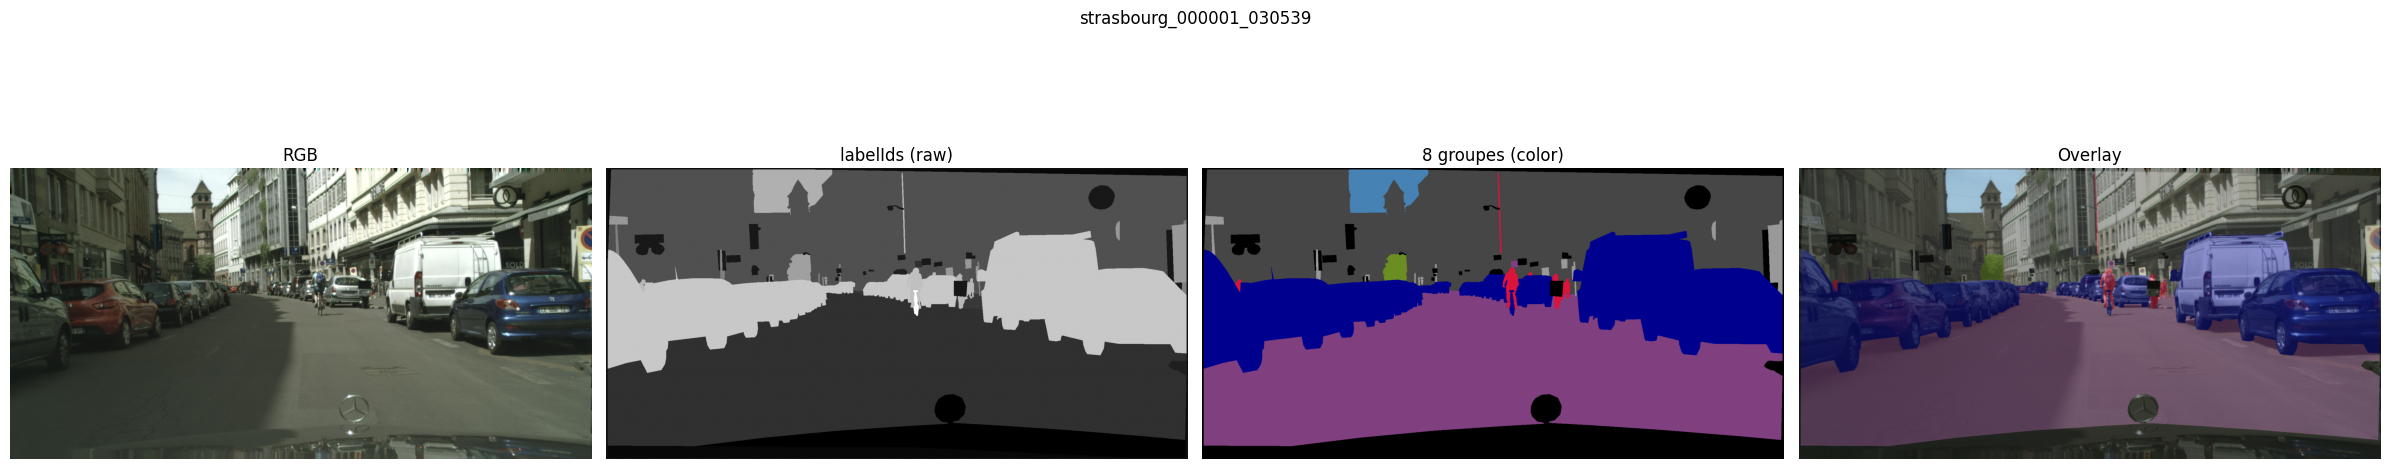

In [10]:
PALETTE = np.array(
    [
        [0, 0, 0],
        [128, 64, 128],
        [70, 70, 70],
        [153, 153, 153],
        [107, 142, 35],
        [70, 130, 180],
        [220, 20, 60],
        [0, 0, 142],
    ],
    dtype=np.uint8,
)


def colorize_groups(mask_groups: Image.Image) -> Image.Image:
    g = np.array(mask_groups, dtype=np.uint8)
    h, w = g.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid = g != IGNORE_LABEL
    rgb[valid] = PALETTE[g[valid]]
    rgb[~valid] = np.array([255, 0, 255], dtype=np.uint8)
    return Image.fromarray(rgb, mode="RGB")


def overlay(img_rgb: Image.Image, mask_rgb: Image.Image, alpha=0.45) -> Image.Image:
    return Image.blend(
        img_rgb.convert("RGBA"), mask_rgb.convert("RGBA"), alpha
    ).convert("RGB")


row = (
    df[(df["split_disk"] == "train") & (df["mask_exists"])]
    .sample(1, random_state=1)
    .iloc[0]
)
img = load_rgb(row["image_path"])
mask_raw = load_mask(row["mask_labelIds_path"])
mask_grp = remap_to_groups(mask_raw, ignore_to_void=False)
mask_col = colorize_groups(mask_grp)
over = overlay(img, mask_col, alpha=0.45)

fig, ax = plt.subplots(1, 4, figsize=(24, 6))
ax[0].imshow(img)
ax[0].set_title("RGB")
ax[0].axis("off")
ax[1].imshow(mask_raw, cmap="gray")
ax[1].set_title("labelIds (raw)")
ax[1].axis("off")
ax[2].imshow(mask_col)
ax[2].set_title("8 groupes (color)")
ax[2].axis("off")
ax[3].imshow(over)
ax[3].set_title("Overlay")
ax[3].axis("off")
plt.suptitle(row["image_id"])
plt.tight_layout()
plt.show()

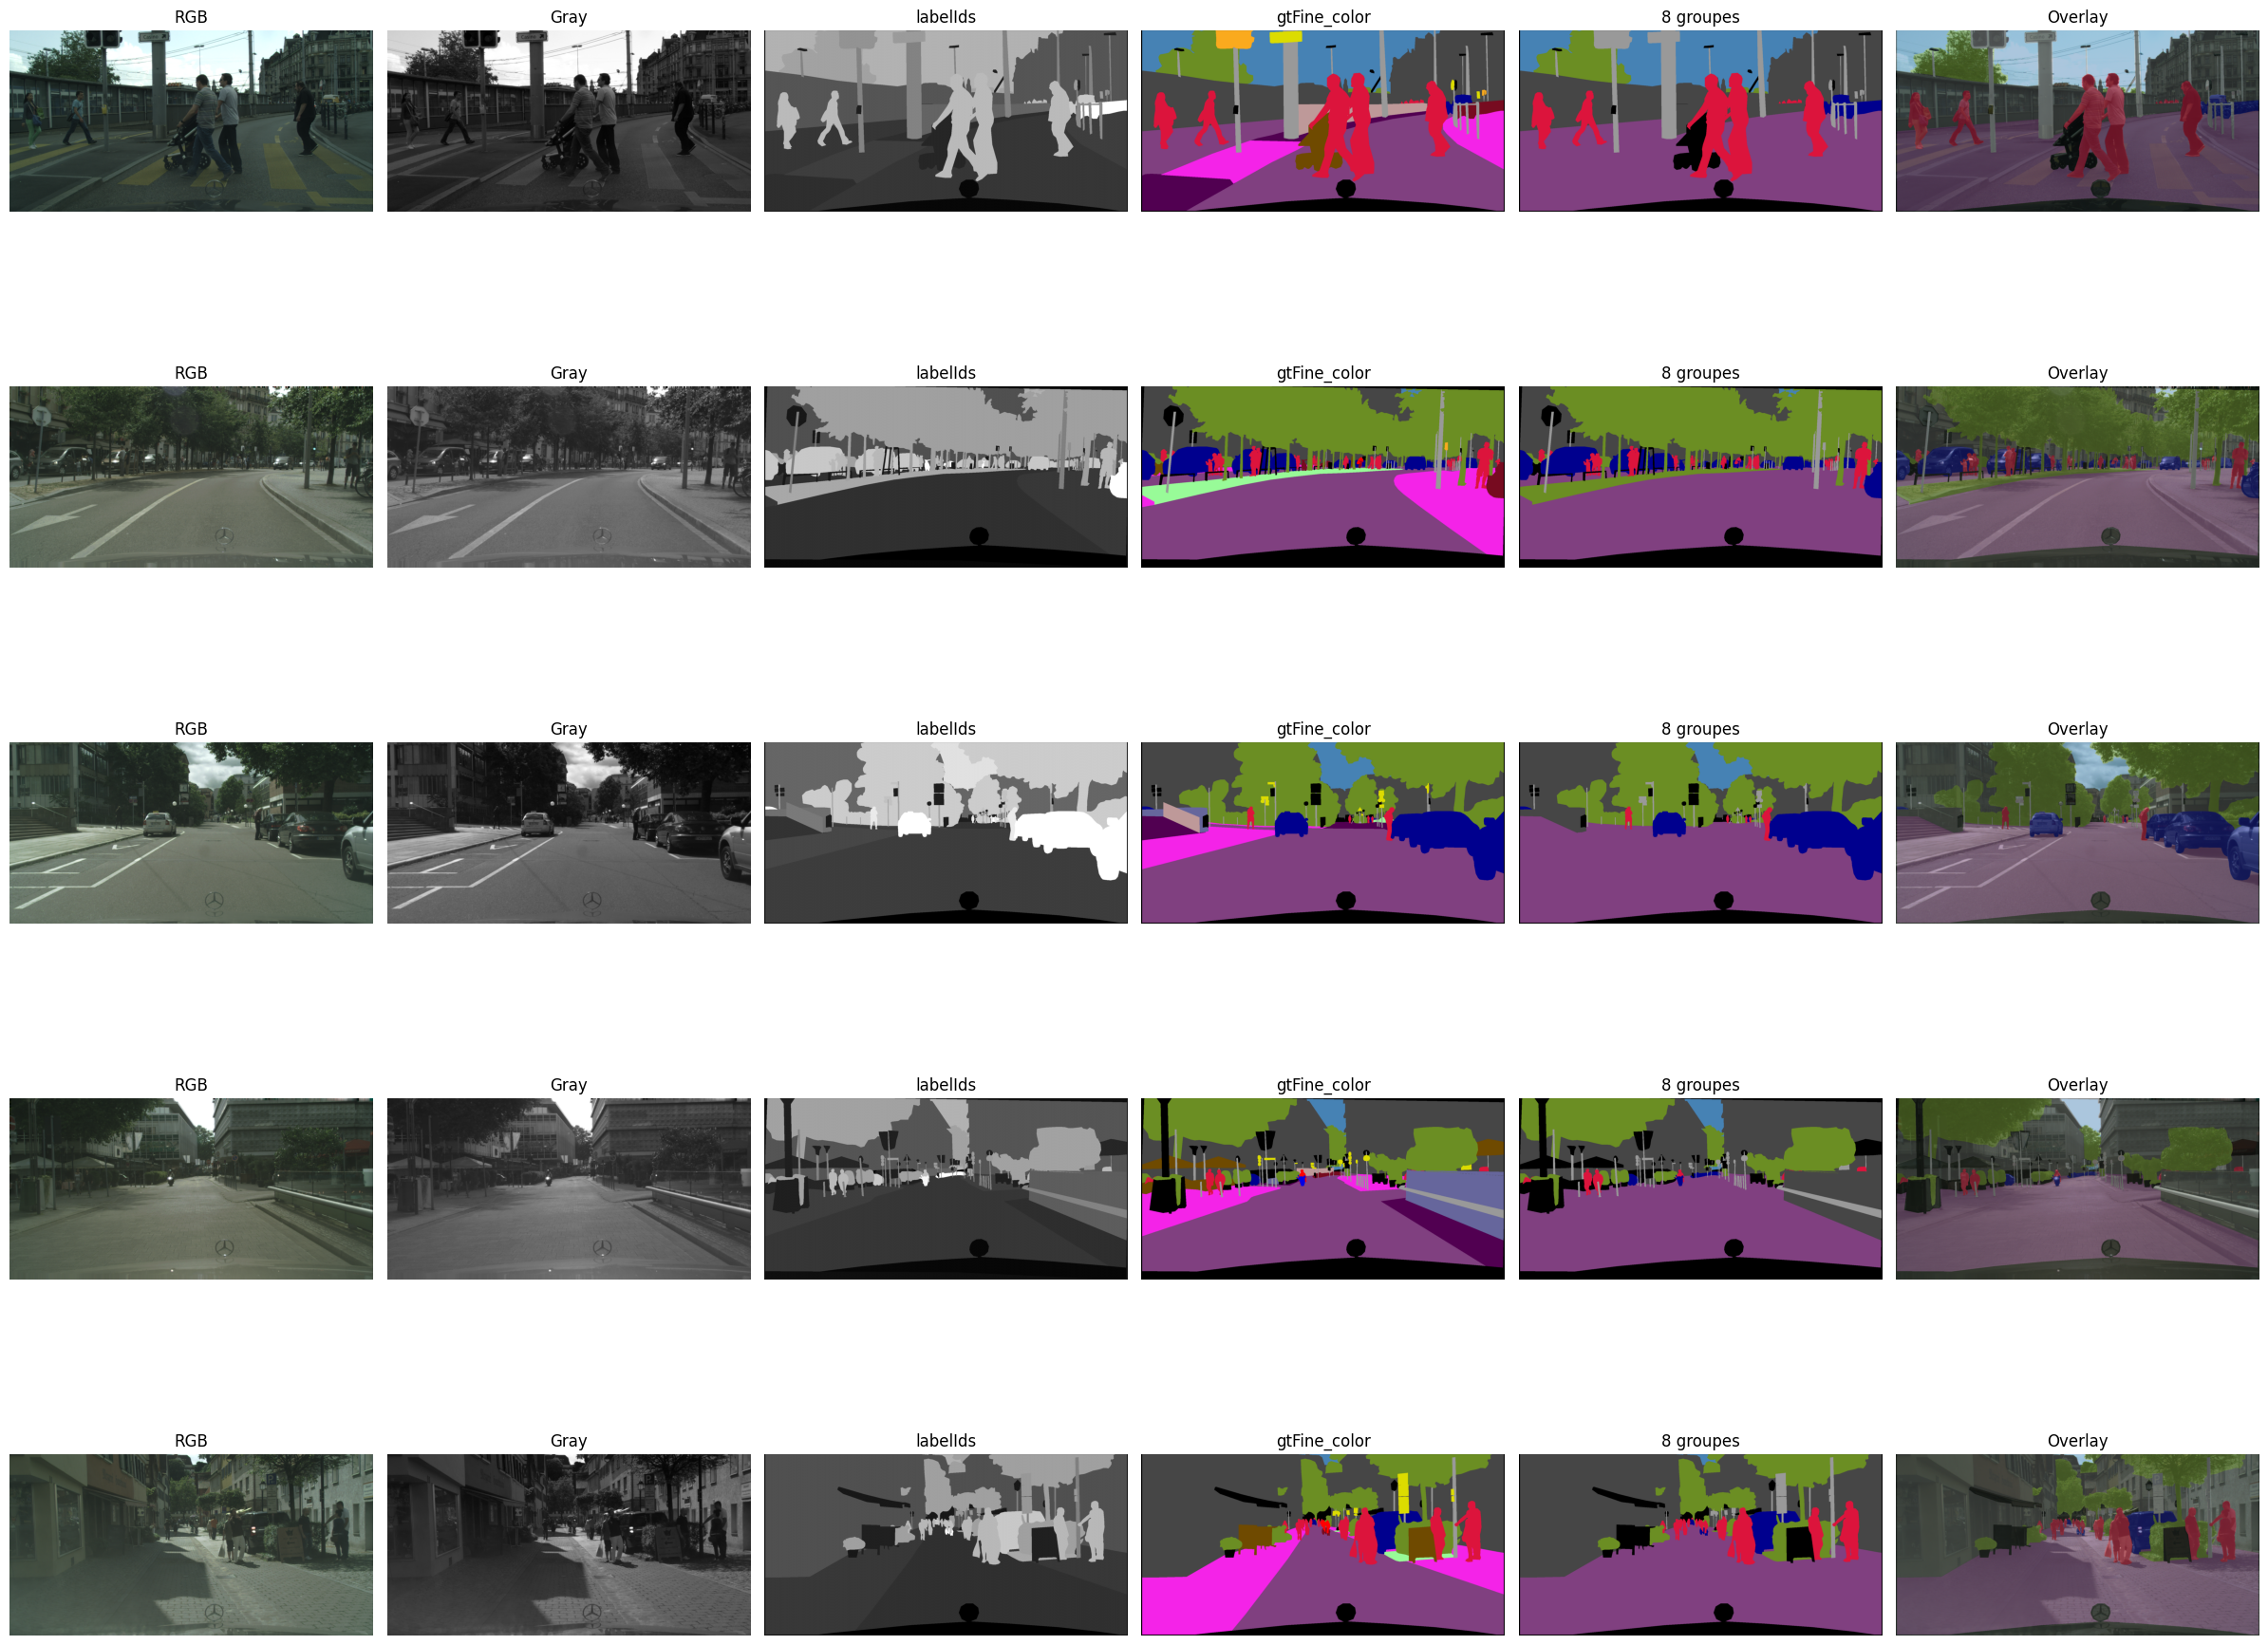

In [11]:
def load_rgb(path: str):
    return Image.open(path).convert("RGB")


def load_mask(path: str):
    return Image.open(path)


def mask_color_path_from_left(img_path: str) -> str:
    p = Path(img_path)
    city = p.parent.name
    split = p.parent.parent.name
    stem = p.name.replace("_leftImg8bit.png", "")
    return str(GT_ROOT / split / city / f"{stem}_gtFine_color.png")


def gallery(df_in, n=6, seed=0):
    sub = df_in[df_in["mask_exists"]].sample(
        min(n, len(df_in[df_in["mask_exists"]])), random_state=seed
    )
    fig, ax = plt.subplots(len(sub), 6, figsize=(24, 4 * len(sub)))
    if len(sub) == 1:
        ax = np.expand_dims(ax, 0)

    for i, (_, r) in enumerate(sub.iterrows()):
        img = load_rgb(r["image_path"])
        gray = img.convert("L")
        raw = load_mask(r["mask_labelIds_path"])
        col_path = mask_color_path_from_left(r["image_path"])
        col_gt = load_rgb(col_path) if Path(col_path).exists() else None

        grp = remap_to_groups(raw, ignore_to_void=False)
        grp_col = colorize_groups(grp)
        ov = overlay(img, grp_col, alpha=0.45)

        ax[i, 0].imshow(img)
        ax[i, 0].set_title("RGB")
        ax[i, 0].axis("off")
        ax[i, 1].imshow(gray, cmap="gray")
        ax[i, 1].set_title("Gray")
        ax[i, 1].axis("off")
        ax[i, 2].imshow(raw, cmap="gray")
        ax[i, 2].set_title("labelIds")
        ax[i, 2].axis("off")
        ax[i, 3].imshow(col_gt if col_gt else grp_col)
        ax[i, 3].set_title("gtFine_color")
        ax[i, 3].axis("off")
        ax[i, 4].imshow(grp_col)
        ax[i, 4].set_title("8 groupes")
        ax[i, 4].axis("off")
        ax[i, 5].imshow(ov)
        ax[i, 5].set_title("Overlay")
        ax[i, 5].axis("off")

    plt.tight_layout()
    plt.show()


gallery(df[df["split_disk"] == "train"], n=5, seed=0)

In [12]:
test_df = df[(df["split_disk"] == "test") & (df["mask_exists"])].copy()
print("Nb images test avec mask_exists=True:", len(test_df))


def black_ratio(mask_pil: Image.Image):
    a = np.array(mask_pil)
    return float((a == 0).mean()), int(len(np.unique(a)))


if len(test_df) > 0:
    samp = test_df.sample(min(10, len(test_df)), random_state=0).copy()
    ratios = []
    for p in samp["mask_labelIds_path"]:
        r, nuniq = black_ratio(load_mask(p))
        ratios.append((r, nuniq))
    samp["black_ratio"] = [x[0] for x in ratios]
    samp["n_unique_values"] = [x[1] for x in ratios]
    samp[["image_id", "black_ratio", "n_unique_values", "mask_labelIds_path"]]

Nb images test avec mask_exists=True: 1525


Nb test avec masks existants: 1525


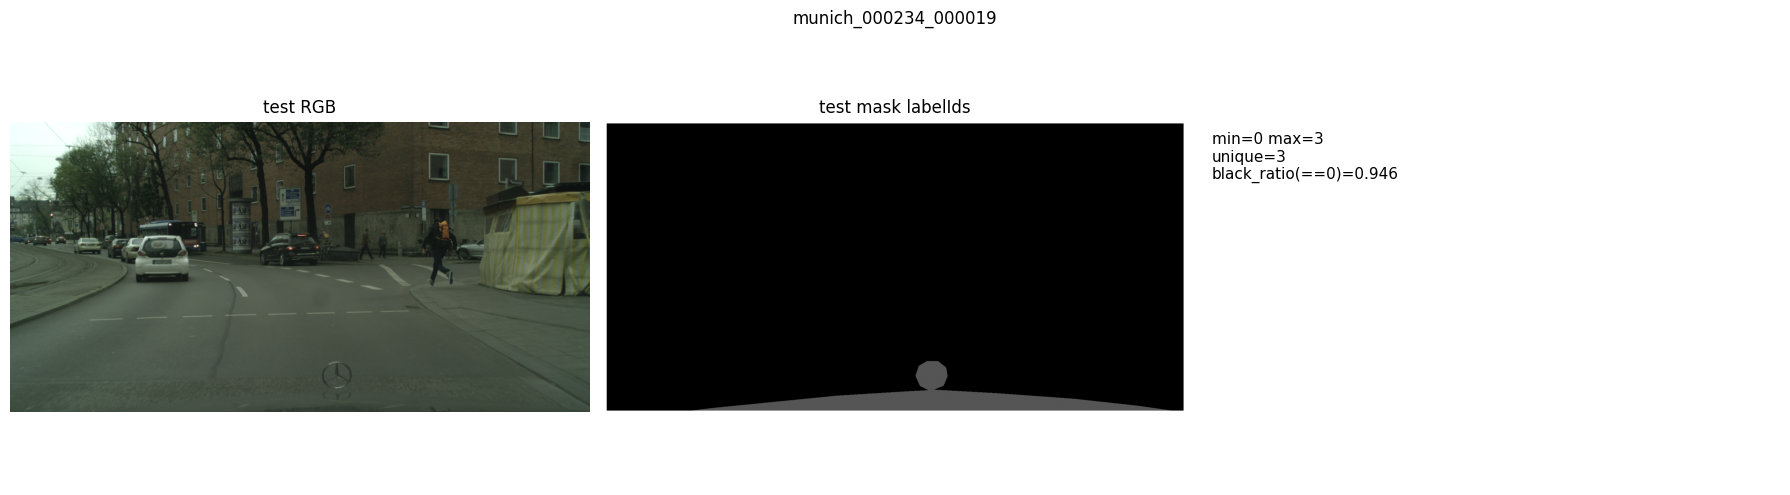

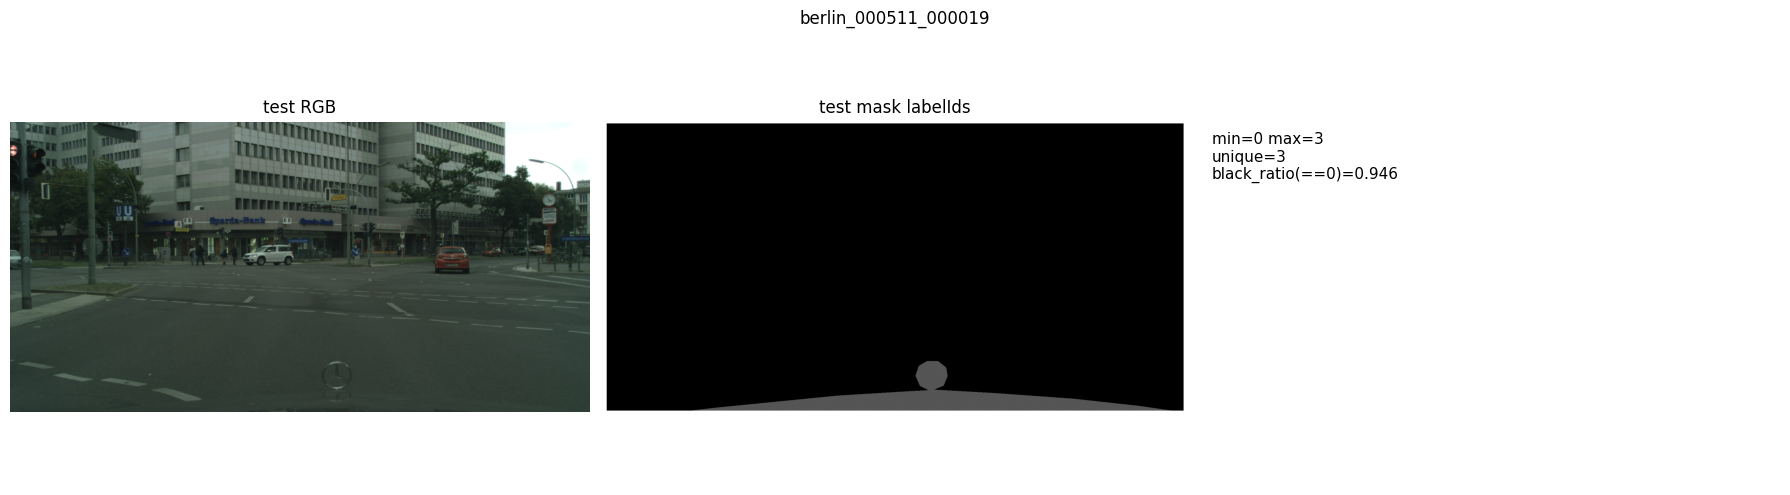

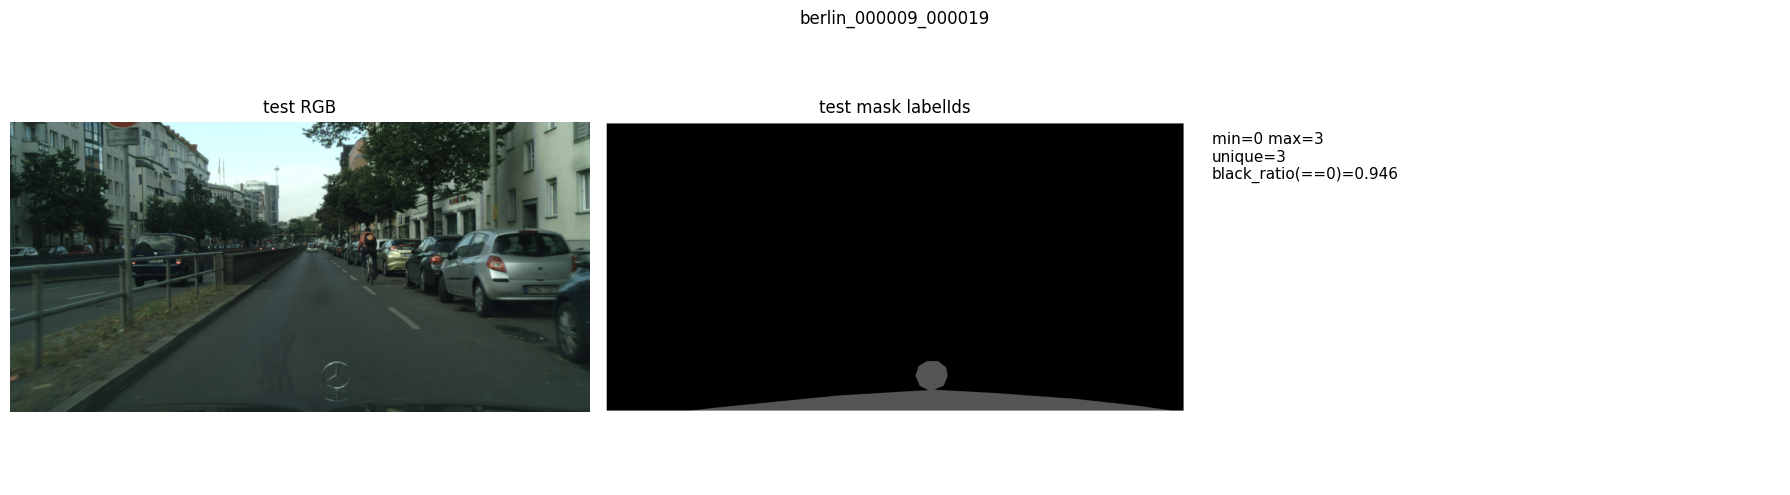

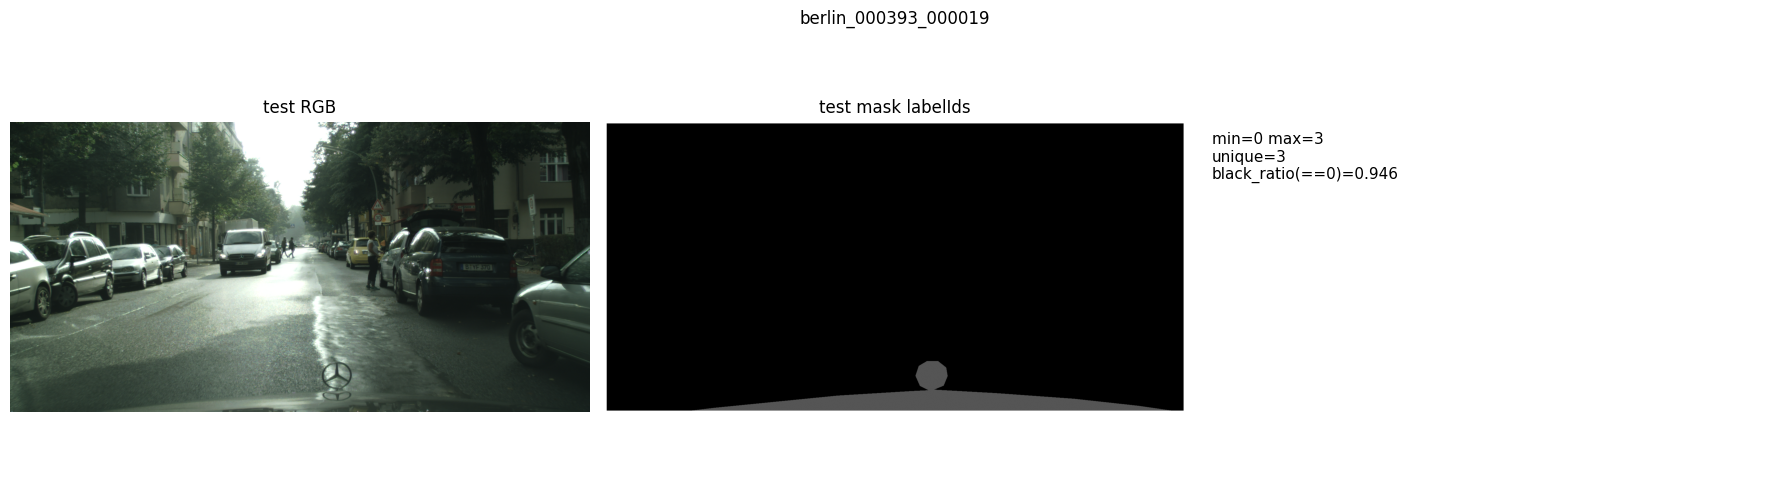

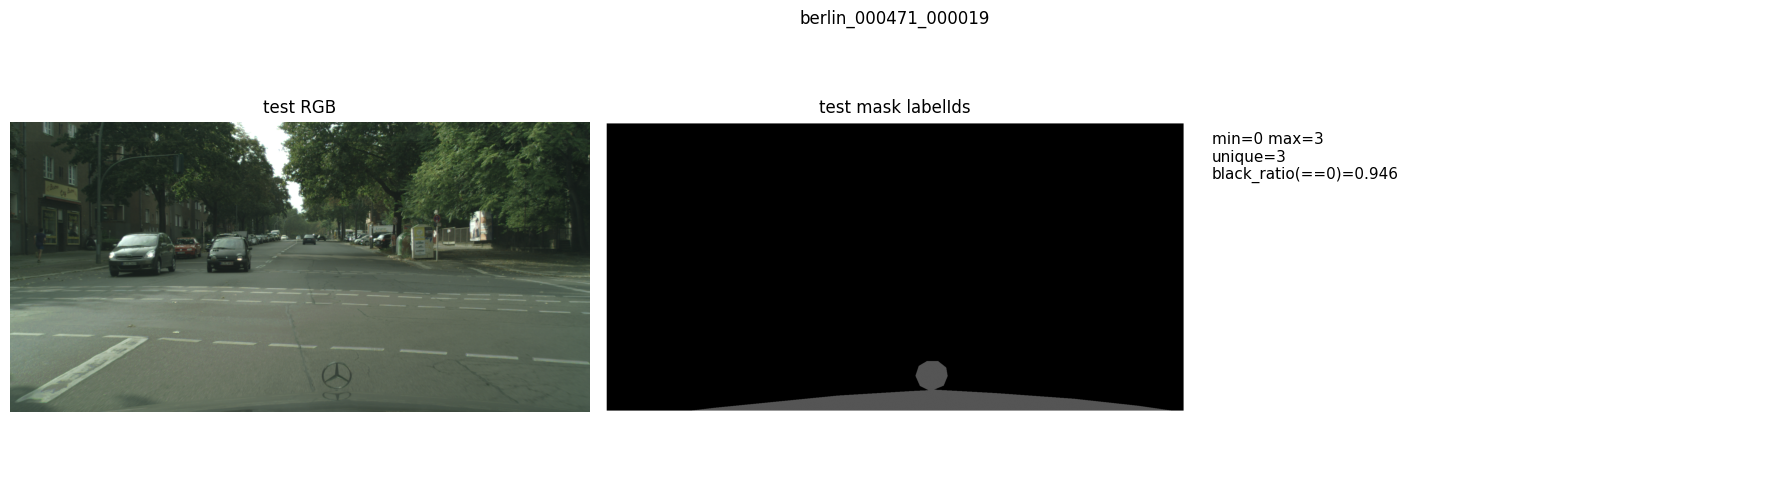

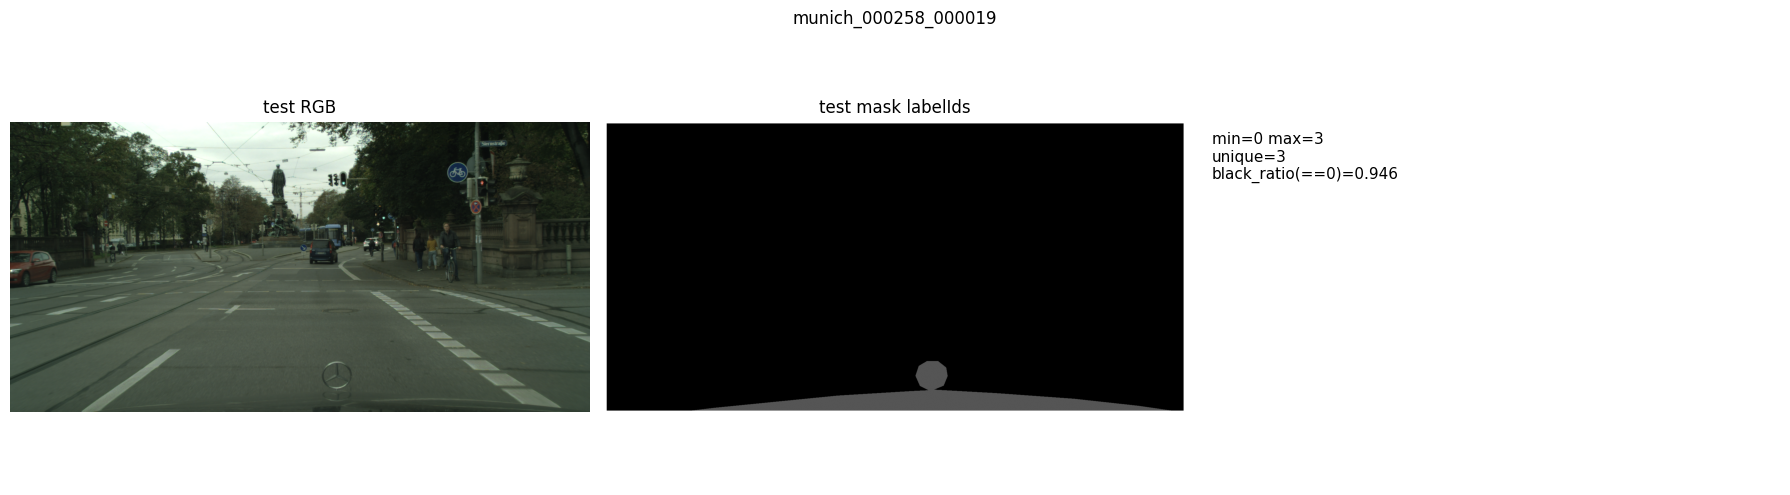

In [13]:
test_with_masks = df[(df["split_disk"] == "test") & (df["mask_exists"])].copy()
print("Nb test avec masks existants:", len(test_with_masks))

if len(test_with_masks) > 0:
    samp = test_with_masks.sample(min(6, len(test_with_masks)), random_state=0)

    for _, r in samp.iterrows():
        img = Image.open(r["image_path"]).convert("RGB")
        m = Image.open(r["mask_labelIds_path"])
        a = np.array(m)

        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        ax[0].imshow(img)
        ax[0].axis("off")
        ax[0].set_title("test RGB")
        ax[1].imshow(m, cmap="gray")
        ax[1].axis("off")
        ax[1].set_title("test mask labelIds")
        ax[2].text(
            0.02,
            0.7,
            f"min={a.min()} max={a.max()}\nunique={len(np.unique(a))}\nblack_ratio(==0)={(a==0).mean():.3f}",
            fontsize=11,
        )
        ax[2].axis("off")
        plt.suptitle(r["image_id"])
        plt.tight_layout()
        plt.show()

Nb masks gtFine_labelIds disponibles en test: 1525


,image_id,city,black_ratio_(a==0),n_unique_values
0,munich_000234_000019,munich,0.946037,3
1,berlin_000511_000019,berlin,0.946037,3
2,berlin_000009_000019,berlin,0.946037,3
3,berlin_000393_000019,berlin,0.946037,3
4,berlin_000471_000019,berlin,0.946037,3
5,munich_000258_000019,munich,0.946037,3
6,bielefeld_000000_027928,bielefeld,0.891840,4
7,berlin_000152_000019,berlin,0.946037,3


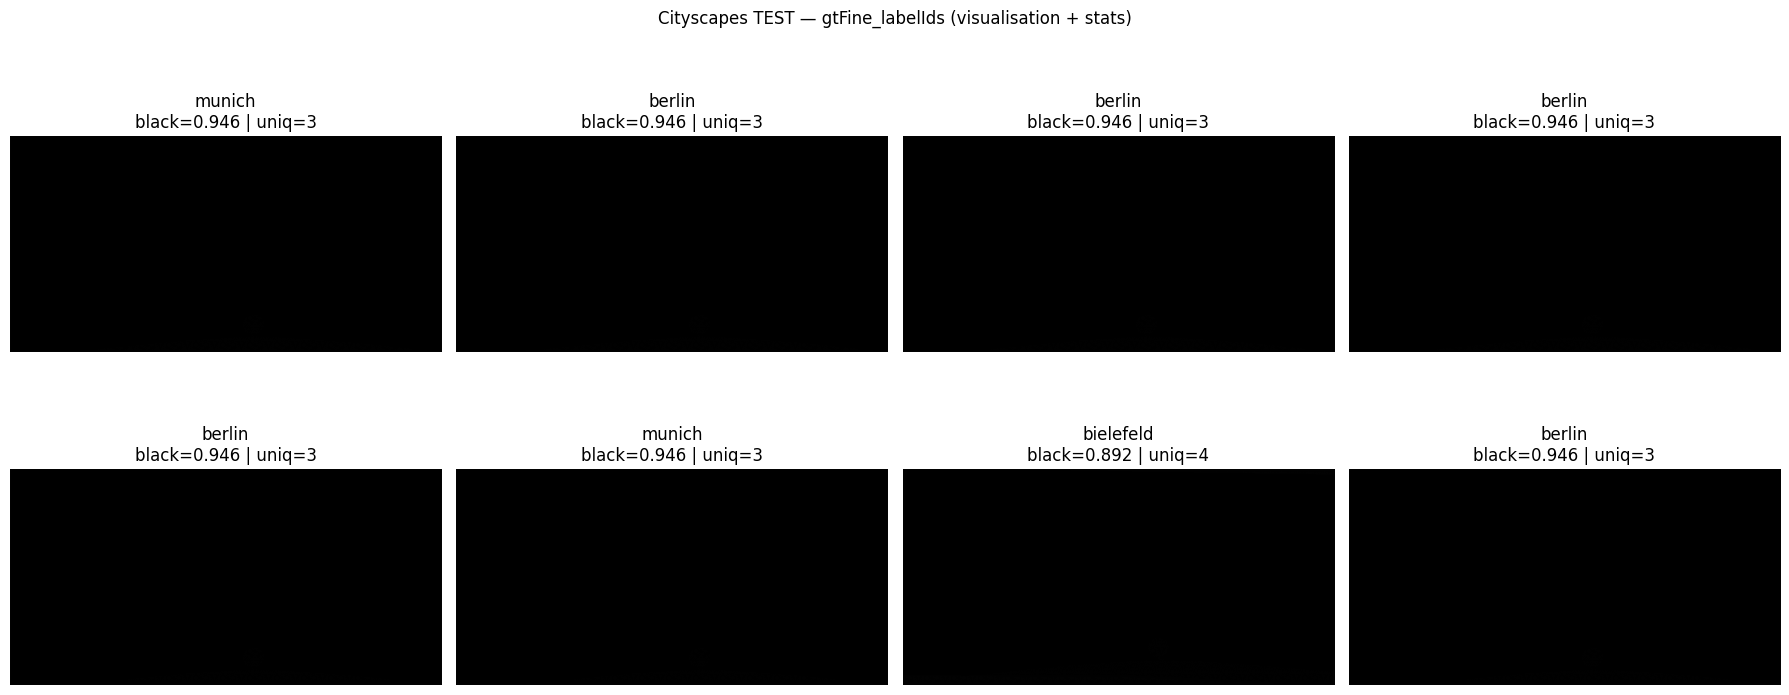

In [14]:
test_gt = df[(df["split_disk"] == "test") & (df["mask_exists"])].copy()
print("Nb masks gtFine_labelIds disponibles en test:", len(test_gt))

if len(test_gt) == 0:
    print("Aucun mask labelIds trouvé en test (normal selon versions Cityscapes).")
else:
    samp = test_gt.sample(min(8, len(test_gt)), random_state=0).reset_index(drop=True)

    stats = []
    for i, r in samp.iterrows():
        m = load_mask(r["mask_labelIds_path"])
        a = np.array(m)

        black_ratio = float((a == 0).mean())
        n_unique = int(len(np.unique(a)))
        stats.append((black_ratio, n_unique))

    samp["black_ratio_(a==0)"] = [s[0] for s in stats]
    samp["n_unique_values"] = [s[1] for s in stats]
    display(samp[["image_id", "city", "black_ratio_(a==0)", "n_unique_values"]])

    fig, ax = plt.subplots(2, 4, figsize=(18, 8))
    ax = ax.flatten()

    for i, r in samp.iterrows():
        m = load_mask(r["mask_labelIds_path"])
        ax[i].imshow(m, cmap="gray", vmin=0, vmax=255)
        ax[i].set_title(
            f"{r['city']}\nblack={samp.loc[i,'black_ratio_(a==0)']:.3f} | uniq={samp.loc[i,'n_unique_values']}"
        )
        ax[i].axis("off")

    plt.suptitle("Cityscapes TEST — gtFine_labelIds (visualisation + stats)")
    plt.tight_layout()
    plt.show()

In [15]:
usable = df[(df["split_disk"].isin(["train", "val"])) & (df["mask_exists"])].copy()
print("Nb images exploitables (train+val):", len(usable))


def presence_vec(g: np.ndarray):
    v = np.zeros((N_CLASSES,), dtype=np.uint8)
    u = np.unique(g)
    for x in u:
        if 0 <= x < N_CLASSES:
            v[x] = 1
    return v


def compute_presence(df_in, n_masks=None, seed=0):
    sub = df_in
    if n_masks is not None:
        sub = sub.sample(min(n_masks, len(sub)), random_state=seed)
    pres = []
    for p in sub["mask_labelIds_path"]:
        g = np.array(
            remap_to_groups(load_mask(p), ignore_to_void=False), dtype=np.uint8
        )
        pres.append(presence_vec(g))
    pres = np.stack(pres, axis=0)
    return pres.mean(axis=0), len(sub)


def compute_pixel_dist(df_in, n_masks=None, seed=0):
    sub = df_in
    if n_masks is not None:
        sub = sub.sample(min(n_masks, len(sub)), random_state=seed)

    counts = np.zeros((N_CLASSES,), dtype=np.int64)
    total_valid = 0
    total_ignore = 0

    for p in sub["mask_labelIds_path"]:
        g = np.array(
            remap_to_groups(load_mask(p), ignore_to_void=False), dtype=np.uint8
        )
        valid = g != IGNORE_LABEL
        total_ignore += int((~valid).sum())
        total_valid += int(valid.sum())
        if valid.any():
            counts += np.bincount(g[valid].flatten(), minlength=N_CLASSES)

    dist = counts / max(total_valid, 1)
    return dist, counts, total_valid, total_ignore, len(sub)


presence, n_pres = compute_presence(usable, n_masks=400, seed=0)
dist, counts, total_valid, total_ignore, n_pix = compute_pixel_dist(
    usable, n_masks=250, seed=0
)

stats = pd.DataFrame(
    {
        "category": CATEGORY_NAMES,
        "%images_present(sample)": presence,
        "pixel%(sample)": dist,
    }
)
stats.sort_values("pixel%(sample)", ascending=False).reset_index(drop=True)

Nb images exploitables (train+val): 3475


,category,%images_present(sample),pixel%(sample)
0,flat,1.0000,0.401911
1,construction,1.0000,0.213143
2,nature,0.9650,0.151243
3,void,1.0000,0.089430
4,vehicle,0.9975,0.080571
5,sky,0.9075,0.035846
6,object,0.9975,0.017328
7,human,0.8300,0.010527


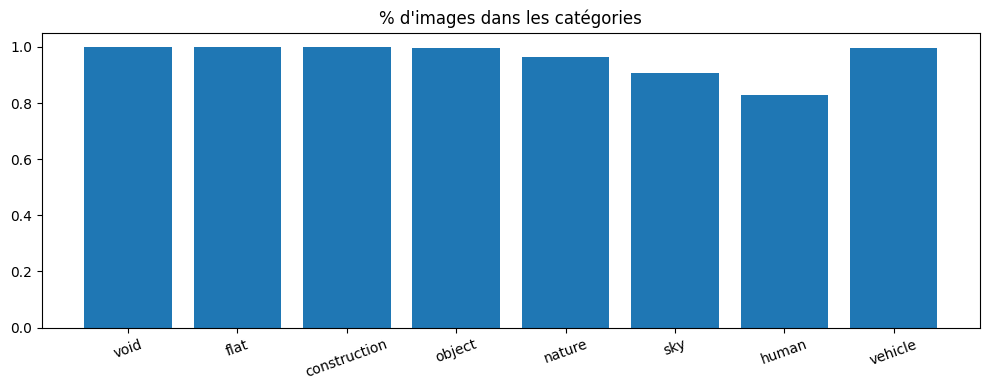

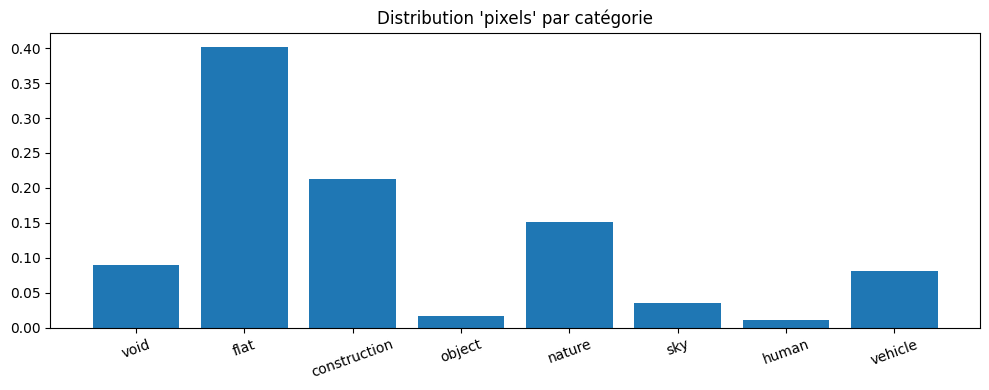

Pixels valides (sample): 524288000
Pixels ignore  (sample): 0


In [16]:
x = np.arange(N_CLASSES)

plt.figure(figsize=(10, 4))
plt.bar(x, presence)
plt.xticks(x, CATEGORY_NAMES, rotation=20)
plt.title("% d'images dans les catégories")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(x, dist)
plt.xticks(x, CATEGORY_NAMES, rotation=20)
plt.title("Distribution 'pixels' par catégorie")
plt.tight_layout()
plt.show()

print("Pixels valides (sample):", total_valid)
print("Pixels ignore  (sample):", total_ignore)

---


Split TRAIN X TEST


In [17]:
SEED = 42

df_gt = df[(df["mask_exists"]) & (df["split_disk"].isin(["train", "val"]))].copy()

train_pool = (
    df_gt[df_gt["split_disk"] == "train"]
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)
n_train = int(0.8 * len(train_pool))

train_pool["split_final"] = "test"
train_pool.loc[: n_train - 1, "split_final"] = "train"

val_pool = df_gt[df_gt["split_disk"] == "val"].copy()
val_pool["split_final"] = "val"

index_final = pd.concat([train_pool, val_pool], ignore_index=True)
index_final["split_final"].value_counts()

split_final
train    2380
test      595
val       500
Name: count, dtype: int64

In [ ]:
BASE = (PROJECT_ROOT / "data" / "raw" / "cityscapes").resolve()


def to_rel(p: str) -> str:
    return str(Path(p).resolve().relative_to(BASE))


index_final["image_rel"] = index_final["image_path"].apply(to_rel)
index_final["mask_rel"] = index_final["mask_labelIds_path"].apply(to_rel)

index_final = index_final.drop(columns=["image_path", "mask_labelIds_path"])

csv_path = OUT_DIR / "cityscapes_split_testXtrainXval.csv"
index_final.to_csv(csv_path, index=False)
print("Saved:", csv_path)

index_final.head()

Saved: /home/ui/PROJ8/out/eda/cityscapes_split_testXtrainXval.csv


,split_disk,city,image_id,mask_exists,split_final,image_rel,mask_rel
0,train,stuttgart,stuttgart_000127_000019,True,train,leftImg8bit/train/stuttgart/stuttgart_000127_0...,gtFine/train/stuttgart/stuttgart_000127_000019...
1,train,zurich,zurich_000012_000019,True,train,leftImg8bit/train/zurich/zurich_000012_000019_...,gtFine/train/zurich/zurich_000012_000019_gtFin...
2,train,strasbourg,strasbourg_000001_031116,True,train,leftImg8bit/train/strasbourg/strasbourg_000001...,gtFine/train/strasbourg/strasbourg_000001_0311...
3,train,bremen,bremen_000237_000019,True,train,leftImg8bit/train/bremen/bremen_000237_000019_...,gtFine/train/bremen/bremen_000237_000019_gtFin...
4,train,stuttgart,stuttgart_000186_000019,True,train,leftImg8bit/train/stuttgart/stuttgart_000186_0...,gtFine/train/stuttgart/stuttgart_000186_000019...
